# **Exporting Google Earth Engine (GEE) Data To Google Colab**

**Why Not Directly Work with GEE Data in Colab?**
GEE API: While GEE has a Python API, it requires internet access and relies on cloud-based processing. This means you interact with the data remotely and cannot directly load it into Colab's memory without exporting it first.

**Memory Limits**: Colab’s memory may not be sufficient for large datasets, especially raster data, so exporting and processing chunks of data is a better strategy.

**Final Thoughts**:
While it would be ideal to work directly with GEE data in Colab, exporting to Google Drive is a practical solution that bridges the cloud-based processing of GEE and local analysis in Colab. By exporting data to Drive, you can take advantage of GEE’s powerful processing capabilities while using Colab for visualization and further processing.

In [ ]:
import os
import requests

# Define the base URL and filenames
base_url = "https://raw.githubusercontent.com/gamamo/AmazonBasinLimits/master/"
filenames = [
    "amazon_sensulatissimo_gmm_v1.shp",
    "amazon_sensulatissimo_gmm_v1.shx",
    "amazon_sensulatissimo_gmm_v1.dbf",
    "amazon_sensulatissimo_gmm_v1.prj"
]

# Create a directory to store the shapefile components
os.makedirs("amazon_basin_shapefile", exist_ok=True)

# Download each file
for filename in filenames:
    url = base_url + filename
    response = requests.get(url)
    if response.status_code == 200:
        with open(os.path.join("amazon_basin_shapefile", filename), "wb") as f:
            f.write(response.content)
        print(f"Downloaded {filename}")
    else:
        print(f"Failed to download {filename}")


Downloaded amazon_sensulatissimo_gmm_v1.shp
Downloaded amazon_sensulatissimo_gmm_v1.shx
Downloaded amazon_sensulatissimo_gmm_v1.dbf
Downloaded amazon_sensulatissimo_gmm_v1.prj


In [ ]:
import geopandas as gpd

# Define the path to the .shp file
shapefile_path = "amazon_basin_shapefile/amazon_sensulatissimo_gmm_v1.shp"

# Read the shapefile
gdf = gpd.read_file(shapefile_path)

# Display the first few rows
gdf.head()

,Id,area,geometry
0,0,0.46,"POLYGON ((-64.37961 -20.20885, -64.38048 -20.2..."
1,0,0.53,"POLYGON ((-64.38048 -20.2021, -64.38372 -20.20..."
2,0,0.01,"POLYGON ((-77.90818 0.20184, -77.90818 0.20762..."
3,0,0.78,"POLYGON ((-77.80988 0.31769, -77.80823 0.3205,..."
4,0,0.29,"POLYGON ((-77.7743 0.40472, -77.77399 0.40869,..."


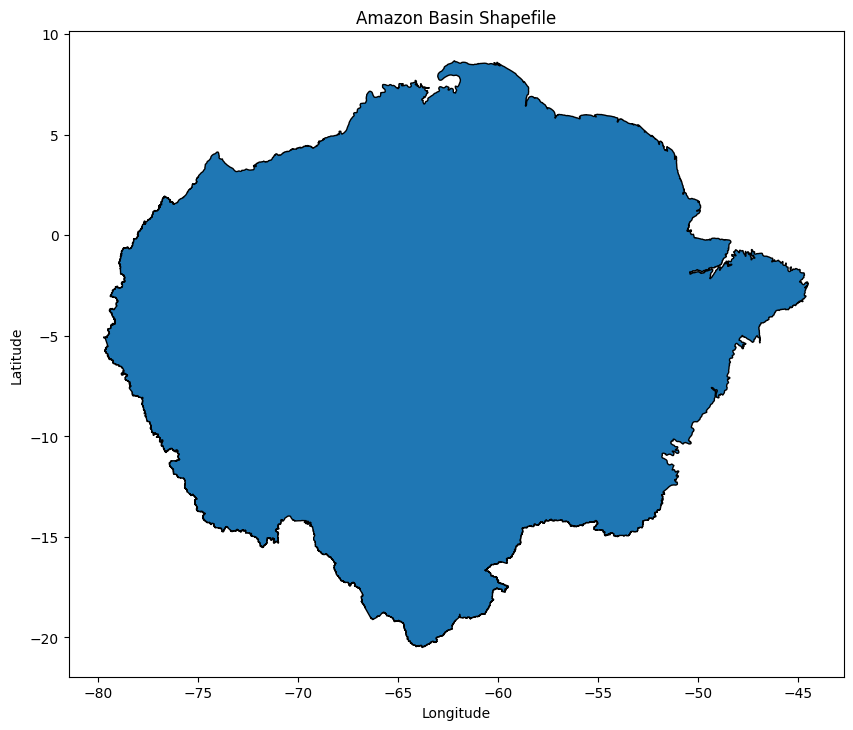

In [ ]:
import matplotlib.pyplot as plt

# Plot the GeoDataFrame
gdf.plot(figsize=(10, 10), edgecolor='black')
plt.title("Amazon Basin Shapefile")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**GEE**

In [ ]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.3 MB/s eta 0:00:00


In [ ]:
import ee

In [ ]:
# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
ee.Initialize(project='gee-')

**Amazon outline GEE**

In [ ]:
import ee
import json

# Assume gdf contains the Amazon basin polygon (not just a bounding box)
amazon_geom = gdf.geometry.iloc[0]  # Extract shapely Polygon
geojson_dict = json.loads(gdf.to_json())['features'][0]['geometry']
amazon_ee_geom = ee.Geometry(geojson_dict)

In [ ]:
from shapely.geometry import mapping
import ee

# Get the full Amazon basin shape and convert to a clean bounding polygon
bbox = gdf.geometry.unary_union.envelope  # or gdf.unary_union if you're confident in the union
amazon_ee_geom = ee.Geometry(mapping(bbox))

/tmp/ipython-input-8-3473601605.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bbox = gdf.geometry.unary_union.envelope  # or gdf.unary_union if you're confident in the union


<ipython-input-9-1800718280>:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  bbox = gdf.geometry.unary_union.envelope
<ipython-input-9-1800718280>:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
<ipython-input-9-1800718280>:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


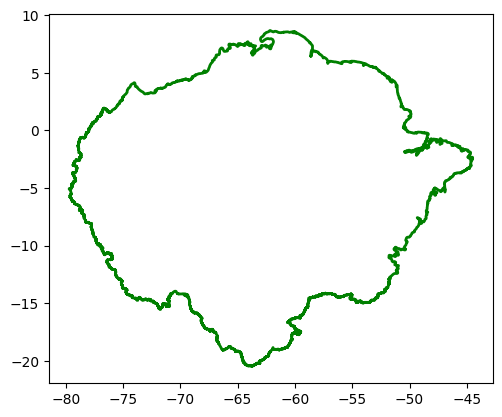

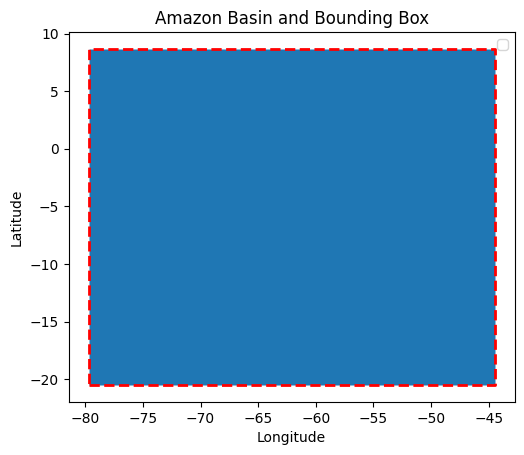

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import mapping

# Original basin GeoDataFrame
gdf.plot(edgecolor='green', facecolor='none', linewidth=2, label='Amazon Basin')

# Plot bounding box
bbox = gdf.geometry.unary_union.envelope
gpd.GeoSeries([bbox]).plot(edgecolor='red', linestyle='--', linewidth=2, label='Bounding Box')

# Make it pretty
plt.title("Amazon Basin and Bounding Box")
plt.legend()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

soil clay- https://developers.google.com/earth-engine/datasets/catalog/OpenLandMap_SOL_SOL_CLAY-WFRACTION_USDA-3A1A1A_M_v02#description

In [ ]:
# Load the dataset
clay = ee.Image('OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02')

# Clip to your Amazon geometry
clay_clipped = clay.clip(amazon_ee_geom)

# Visualization parameters
vis_params = {
    'bands': ['b0'],
    'min': 2,
    'max': 100,
    'palette': [
        'ffff00', 'f8f806', 'f1f10c', 'ebeb13', 'e4e419', 'dddd20',
        'd7d726', 'd0d02d', 'caca33', 'c3c33a', 'bcbc41', 'b6b647',
        'b0b04e', 'a9a954', 'a3a35a', '9c9c61', '959568', '8f8f6e',
        '898975', '82827b', '7b7b82', '757589', '6e6e8f', '686895',
        '61619c', '5a5aa3', '5454a9', '4d4db0', '4747b6', '4141bc',
        '3a3ac3', '3333ca', '2d2dd0', '2626d7', '2020dd', '1919e4',
        '1212eb', '0c0cf1', '0606f8', '0000ff',
    ]
}

# Get thumbnail URL for quick preview
thumb_url = clay_clipped.getThumbURL({
    'region': amazon_ee_geom,
    'dimensions': 1024,
    **vis_params
})

print("🖼️ Clay preview:", thumb_url)

🖼️ Clay preview: https://earthengine.googleapis.com/v1/projects/gee-ai-test1/thumbnails/eada7f4d74d45a334c08085e852fac2e-9351b19cf915b934b8b64035efc3446f:getPixels


In [ ]:
# Load the Clay dataset
clay = ee.Image('OpenLandMap/SOL/SOL_CLAY-WFRACTION_USDA-3A1A1A_M/v02')

# Clip to your Amazon geometry (replace amazon_ee_geom with your geometry)
clay_clipped = clay.clip(amazon_ee_geom)

# Select the b0 band (the first band of the dataset)
clay_b0 = clay_clipped.select('b0')

# Define the export task
export_task = ee.batch.Export.image.toDrive(
    image=clay_b0,  # Image to export
    description='Clay_b0_Export',  # Task description
    folder='earthworks',  # Folder on Google Drive
    fileNamePrefix='clay_b0',  # Name prefix for the exported file
    region=amazon_ee_geom,  # Define the region to export (ensure it's in the right CRS)
    scale=1000,  # Define the scale (e.g., 30 meters)
    crs='EPSG:4326',  # Define the CRS (WGS84)
    fileFormat='GeoTIFF',  # Export format
    maxPixels=1e13
)

# Start the export task
export_task.start()

print("✅ Export task started. You can monitor its status in the Google Earth Engine Code Editor.")

✅ Export task started. You can monitor its status in the Google Earth Engine Code Editor.


SOC- Soil Organic Carbon Content: https://developers.google.com/earth-engine/datasets/catalog/OpenLandMap_SOL_SOL_ORGANIC-CARBON_USDA-6A1C_M_v02

In [ ]:
# Load the dataset
soc = ee.Image('OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02')

# Clip to your Amazon geometry
soc_clipped = soc.clip(amazon_ee_geom)

# Visualization parameters
vis_params = {
    'bands': ['b0'],
    'min': 2,
    'max': 120,
    'palette': [
        'ffffa0','f7fcb9','d9f0a3','addd8e','78c679','41ab5d',
    '238443','005b29','004b29','012b13','00120b',
    ]
}

# Get thumbnail URL for quick preview
thumb_url = soc_clipped.getThumbURL({
    'region': amazon_ee_geom,
    'dimensions': 1024,
    **vis_params
})

print("🖼️ SOC preview:", thumb_url)

🖼️ SOC preview: https://earthengine.googleapis.com/v1/projects/gee-ai-test1/thumbnails/4276efe97f9c57daf14535d3a377727d-862d550cbcc7b035519b1a8d94fdb6a1:getPixels


In [ ]:
# Load the Clay dataset
soc = ee.Image('OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02')

# Clip to your Amazon geometry (replace amazon_ee_geom with your geometry)
soc_clipped = soc.clip(amazon_ee_geom)

# Select the b0 band (the first band of the dataset)
soc_b0 = soc_clipped.select('b0')

# Define the export task
export_task = ee.batch.Export.image.toDrive(
    image=soc_b0,  # Image to export
    description='SOC_b0_Export',  # Task description
    folder='earthworks',  # Folder on Google Drive
    fileNamePrefix='soc_b0',  # Name prefix for the exported file
    region=amazon_ee_geom,  # Define the region to export (ensure it's in the right CRS)
    scale=1000,  # Define the scale (e.g., 30 meters)
    crs='EPSG:4326',  # Define the CRS (WGS84)
    fileFormat='GeoTIFF',  # Export format
    maxPixels=1e13
)

# Start the export task
export_task.start()

print("✅ Export task started. You can monitor its status in the Google Earth Engine Code Editor.")

✅ Export task started. You can monitor its status in the Google Earth Engine Code Editor.


**soil ph**

In [ ]:
# Load the dataset
ph = ee.Image('OpenLandMap/SOL/SOL_PH-H2O_USDA-4C1A2A_M/v02')

# Clip to your Amazon geometry
ph_clipped = ph.clip(amazon_ee_geom)

# Visualization parameters
vis_params = {
    'bands': ['b0'],
    'min': 42,
    'max': 110,
    'palette': [
        'ff0000', 'ff1c00', 'ff3900', 'ff5500', 'ff7100', 'ff8e00',
    'ffaa00', 'ffc600', 'ffe200', 'ffff00', 'e3ff00', 'c7ff00',
    'aaff00', '8eff00', '72ff00', '55ff00', '39ff00', '1dff00',
    '01ff00', '00ff1c', '00ff38', '00ff54', '00ff71', '00ff8d',
    '00ffa9', '00ffc6', '00ffe2', '00fffe', '00e3ff', '00c7ff',
    '00abff', '008fff', '0072ff', '0056ff', '003aff', '001dff',
    '0001ff', '1b00ff', '3800ff', '5400ff',
    ]
}

# Get thumbnail URL for quick preview
thumb_url = ph_clipped.getThumbURL({
    'region': amazon_ee_geom,
    'dimensions': 1024,
    **vis_params
})

print("🖼️ ph preview:", thumb_url)

🖼️ ph preview: https://earthengine.googleapis.com/v1/projects/gee-ai-test1/thumbnails/d82603d5908e974bf20a5c7e5d89c0b5-97e8892ead6c18e2fc7370eef1938ecd:getPixels


In [ ]:
# Load the Clay dataset
ph = ee.Image('OpenLandMap/SOL/SOL_PH-H2O_USDA-4C1A2A_M/v02')

# Clip to your Amazon geometry (replace amazon_ee_geom with your geometry)
ph_clipped = ph.clip(amazon_ee_geom)

# Select the b0 band (the first band of the dataset)
ph_b0 = ph_clipped.select('b0')

# Define the export task
export_task = ee.batch.Export.image.toDrive(
    image=ph_b0,  # Image to export
    description='SOC_b0_Export',  # Task description
    folder='earthworks',  # Folder on Google Drive
    fileNamePrefix='ph_b0',  # Name prefix for the exported file
    region=amazon_ee_geom,  # Define the region to export (ensure it's in the right CRS)
    scale=1000,  # Define the scale (e.g., 30 meters)
    crs='EPSG:4326',  # Define the CRS (WGS84)
    fileFormat='GeoTIFF',  # Export format
    maxPixels=1e13
)

# Start the export task
export_task.start()

print("✅ Export task started. You can monitor its status in the Google Earth Engine Code Editor.")

✅ Export task started. You can monitor its status in the Google Earth Engine Code Editor.


**texture**

In [ ]:
# Load the dataset
txt = ee.Image('OpenLandMap/SOL/SOL_TEXTURE-CLASS_USDA-TT_M/v02')

# Clip to your Amazon geometry
txt_clipped = txt.clip(amazon_ee_geom)

# Visualization parameters
vis_params = {
    'bands': ['b0'],
    'min': 1,
    'max': 12,
    'palette': [
        'd5c36b','b96947','9d3706','ae868f','f86714','46d143',
    '368f20','3e5a14','ffd557','fff72e','ff5a9d','ff005b',
    ]
}

# Get thumbnail URL for quick preview
thumb_url = txt_clipped.getThumbURL({
    'region': amazon_ee_geom,
    'dimensions': 1024,
    **vis_params
})

print("🖼️ Soil texture preview:", thumb_url)

🖼️ Soil texture preview: https://earthengine.googleapis.com/v1/projects/gee-ai-test1/thumbnails/e0acf5156751ef8b3ff6e5647de59999-dfe95ce6a9056e85d79002ffd5802662:getPixels


In [ ]:
# Load the Clay dataset
txt = ee.Image('OpenLandMap/SOL/SOL_TEXTURE-CLASS_USDA-TT_M/v02')

# Clip to your Amazon geometry (replace amazon_ee_geom with your geometry)
txt_clipped = txt.clip(amazon_ee_geom)

# Select the b0 band (the first band of the dataset)
txt_b0 = txt_clipped.select('b0')

# Define the export task
export_task = ee.batch.Export.image.toDrive(
    image=txt_b0,  # Image to export
    description='soilTxt_b0_Export',  # Task description
    folder='earthworks',  # Folder on Google Drive
    fileNamePrefix='txt_b0',  # Name prefix for the exported file
    region=amazon_ee_geom,  # Define the region to export (ensure it's in the right CRS)
    scale=1000,  # Define the scale (e.g., 30 meters)
    crs='EPSG:4326',  # Define the CRS (WGS84)
    fileFormat='GeoTIFF',  # Export format
    maxPixels=1e13
)

# Start the export task
export_task.start()

print("✅ Export task started. You can monitor its status in the Google Earth Engine Code Editor.")

✅ Export task started. You can monitor its status in the Google Earth Engine Code Editor.


**bulk density**
https://developers.google.com/earth-engine/datasets/catalog/OpenLandMap_SOL_SOL_BULKDENS-FINEEARTH_USDA-4A1H_M_v02

In [ ]:
# Load the dataset
bulkden = ee.Image('OpenLandMap/SOL/SOL_BULKDENS-FINEEARTH_USDA-4A1H_M/v02')

# Clip to your Amazon geometry
bulkden_clipped = bulkden.clip(amazon_ee_geom)

# Visualization parameters
vis_params = {
    'bands': ['b0'],
    'min': 5,
    'max': 185,
    'palette': [
        '5e3c99', 'b2abd2', 'f7e0b2', 'fdb863', 'e63b01',
    ]
}

# Get thumbnail URL for quick preview
thumb_url = bulkden_clipped.getThumbURL({
    'region': amazon_ee_geom,
    'dimensions': 1024,
    **vis_params
})

print("🖼️ Bulk density preview:", thumb_url)

🖼️ Bulk density preview: https://earthengine.googleapis.com/v1/projects/gee-ai-test1/thumbnails/eb2894e767309fa2d3e36ba1257009b9-3058eeee611e5f5d36a4f43e5f0c2a15:getPixels


**Bioclimatic variables**

In [ ]:
import ee


# Replace with your own amazon_ee_geom if needed
# amazon_ee_geom = ee.Geometry(...)

# Load dataset
dataset = ee.Image("WORLDCLIM/V1/BIO").clip(amazon_ee_geom)

# Conversion factors for temperature bands
temp_scaling = 0.1
temp_01_11 = ['bio01','bio02','bio05','bio06','bio07','bio08','bio09','bio10','bio11']
temp_04 = ['bio04']  # needs 0.01 scaling
# No scaling for precipitation or percent

# Visualization parameters for key bands (feel free to adjust)
visualization_params = {
    'bio01': {'min': -29, 'max': 32, 'palette': ['blue', 'purple', 'cyan', 'green', 'yellow', 'red']},
    'bio12': {'min': 0, 'max': 5000, 'palette': ['white', 'blue', 'green', 'yellow', 'red']},
    'bio04': {'min': 0, 'max': 230, 'palette': ['white', 'orange', 'red']}
}

# Apply scaling
scaled_bands = []
for band in dataset.bandNames().getInfo():
    image = dataset.select(band)
    if band in temp_01_11:
        image = image.multiply(0.1)
    elif band in temp_04:
        image = image.multiply(0.01)
    # Rename for clarity
    scaled_bands.append(image.rename(band))

# Merge into a new image
climate_image = ee.Image.cat(scaled_bands)

# Example: generate thumbnail for bio01
bio01_thumb = climate_image.select('bio01').getThumbURL({
    'region': amazon_ee_geom,
    'dimensions': 1024,
    **visualization_params['bio01']
})
print("🧊 Annual Mean Temperature (bio01):", bio01_thumb)

# Example: generate thumbnail for bio12
bio12_thumb = climate_image.select('bio12').getThumbURL({
    'region': amazon_ee_geom,
    'dimensions': 1024,
    **visualization_params['bio12']
})
print("💧 Annual Precipitation (bio12):", bio12_thumb)


🧊 Annual Mean Temperature (bio01): https://earthengine.googleapis.com/v1/projects/gee-ai-test1/thumbnails/734dad3d7e7256697c1c8aa3aff6fcf2-ced72306b1f0e14f5859789125741154:getPixels
💧 Annual Precipitation (bio12): https://earthengine.googleapis.com/v1/projects/gee-ai-test1/thumbnails/01d0434abdcf874328365064d9ad675a-ccea9c654ee71b9527813ebfc031c938:getPixels


In [ ]:
# Load and clip dataset
dataset = ee.Image("WORLDCLIM/V1/BIO").clip(amazon_ee_geom)

# Define temperature scaling
temp_scaling = 0.1
temp_01_11 = ['bio01','bio02','bio05','bio06','bio07','bio08','bio09','bio10','bio11']
temp_04 = ['bio04']

# Define export folder
export_folder = 'AmazonClimate_Bands'

# Loop through bands and export
for band in dataset.bandNames().getInfo():
    image = dataset.select(band)

    # Scale appropriately
    if band in temp_01_11:
        image = image.multiply(0.1)
    elif band in temp_04:
        image = image.multiply(0.01)

    # Rename for clarity
    image = image.rename(band)

    # Set export task
    task = ee.batch.Export.image.toDrive(
        image=image,
        description=f"export_{band}",
        folder=export_folder,
        fileNamePrefix=band,
        region=amazon_ee_geom,
        scale=1000,  # adjust as needed for resolution
        maxPixels=1e13
    )
    task.start()
    print(f"🔁 Export started for {band}")

🔁 Export started for bio01
🔁 Export started for bio02
🔁 Export started for bio03
🔁 Export started for bio04
🔁 Export started for bio05
🔁 Export started for bio06
🔁 Export started for bio07
🔁 Export started for bio08
🔁 Export started for bio09
🔁 Export started for bio10
🔁 Export started for bio11
🔁 Export started for bio12
🔁 Export started for bio13
🔁 Export started for bio14
🔁 Export started for bio15
🔁 Export started for bio16
🔁 Export started for bio17
🔁 Export started for bio18
🔁 Export started for bio19


In [ ]:
# Step 1: Load the GFPLAIN250 ImageCollection
gfplain_ic = ee.ImageCollection("projects/sat-io/open-datasets/GFPLAIN250")

# Step 2: Mosaic and clip to Amazon geometry
gfplain_mosaic = gfplain_ic.mosaic().clip(amazon_ee_geom)

# Step 3: Optional visualization
import folium
from geemap import foliumap

# Center map somewhere in Amazon
center = amazon_ee_geom.centroid().coordinates().getInfo()
m = folium.Map(location=center[::-1], zoom_start=6)

# Add GFPLAIN layer
gfplain_vis = {
    'min': 0,
    'max': 1,
    'palette': ['white', 'green']
}
map_id_dict = gfplain_mosaic.getMapId(gfplain_vis)
folium.TileLayer(
    tiles=map_id_dict['tile_fetcher'].url_format,
    attr='Earth Engine',
    name='GFPLAIN250',
    overlay=True
).add_to(m)

# Show map
folium.LayerControl().add_to(m)
m

In [ ]:
print(gfplain_mosaic.getInfo())  # Should print metadata


{'type': 'Image', 'bands': [{'id': 'b1', 'data_type': {'type': 'PixelType', 'precision': 'int', 'min': 0, 'max': 255}, 'dimensions': [38, 32], 'origin': [-81, -22], 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}], 'properties': {'system:footprint': {'type': 'Polygon', 'coordinates': [[[-79.69977099999988, -20.493751999999915], [-44.49108565540848, -20.493751999999915], [-44.49108565540848, 8.663513024011024], [-79.69977099999988, 8.663513024011024], [-79.69977099999988, -20.493751999999915]]]}}}


In [ ]:
import ee
import geemap

In [ ]:

# Load GFPLAIN250 floodplain raster
gfplain = ee.ImageCollection("projects/sat-io/open-datasets/GFPLAIN250").mosaic().clip(amazon_ee_geom)

# Threshold floodplain (value == 1)
floodplain_mask = gfplain.eq(1).selfMask()

# Convert raster to vector polygons
floodplain_vector = floodplain_mask.reduceToVectors(
    geometry=amazon_ee_geom,
    geometryType='polygon',
    scale=250,
    maxPixels=1e9
)

# Buffer each polygon by 10 km
floodplain_buffer = floodplain_vector.map(lambda f: f.buffer(10000))  # 10,000 meters

# Visualize using folium
Map = geemap.Map(center=[-8, -70], zoom=6)
Map.addLayer(floodplain_buffer, {"color": "blue"}, "10km Floodplain Buffer")
Map.addLayer(gfplain, {"min": 0, "max": 1, "palette": ["white", "green"]}, "GFPLAIN250")
Map

Map(center=[-8, -70], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(chi…

**-----------------------------------------------------------------------------------------------------**

floodplain
https://www.sciencedirect.com/science/article/pii/S1470160X1830880X

https://gee-community-catalog.org/projects/gfplain250/#data-citation

fabdem- https://gee-community-catalog.org/projects/fabdem/#citation